<a href="https://colab.research.google.com/github/joanne-gazmen/Data201-Spring2026/blob/main/Data201_JGazmen_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data 201 Project 1**

Author: Joanne Gazmen

Date: 03/11/26

Presentation Link: https://docs.google.com/presentation/d/1joCMaMFTZVDFFS1ankRdKVYBa_ixG2O-NzqZ5icLyhw/edit?usp=sharing

### **Introduction:**

For this project, I decided to make an analysis on whether or not income correlates to Adults (In the U.S) demographics/lifestyles/ages/relationships/and more. The dataset I've decided to use is the "Adult" dataset from UC Irvine Machine Learning Repository. This dataset has 48842 rows/instances and 14 variables. I think dataset is really good, because I plan to show different analyses to see if working more can earn more or less than 50k, if age earns more than 50k, does education level affect income?, and do different occupations have different income distributions? The data was collected through the U.S. Census, which gathers demographic and economic information from households across the country through surveys and official census forms. Respondents provide information about their employment, income, education level, family structure, and other demographic characteristics.

One limitation I found was the reliability of the source. Although census data is generally reliable due to its large sample size, the first limitation was that the data is self-reported, which means individuals may provide inaccurate information either intentionally or unintentionally. Second, the dataset was derived from census data collected in the early 1990s, so it may not accurately represent modern labor market conditions or income patterns. Lastly,the dataset simplifies income into only two categories (above or below $50,000), which removes detail about the actual income distribution and may limit deeper analysis(I wish the actual number of income at was at least by the nearest thousand). As for any potential ethical or bias concerns, There were multiple potential ethical and bias concerns associated with this dataset. One I could potentially see is how this dataset includes demographic variables such as race, gender, and country of origin, models that could unintentionally reinforce existing social or economic inequalities. For example, if historical data reflects systemic disparities in income between groups, predictive models trained on this data might replicate or amplify those patterns. Another potential concern could be sampling bias, because although the census aims to be comprehensive, certain populations may be underrepresented due to non-response, limited access, or socioeconomic barriers. This can affect how accurately the dataset represents the full U.S. population.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Import/read dataset
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### **Data Structure:**

| Name | Description/Explanation | Type
|---|---|---|
| age | adult ages (17-90) | Integer |
| workclass | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. | Categorical|
| fnlwgt | Stands for "Final Weight": Meaning The weight helps adjust the data so it better represents the entire population. Example: fnlwgt = 200000 it means that person’s record statistically represents about 200,000 similar people in the population. | Integer |
| education | Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. | Categorical |
| education_num | Same education levels, in numerical order. (1-Preschool ~ 16-Doctorate) | Integer |
| marital_status | 	Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. | Categorical |
| occupation | 	Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. | Categorical |
| relationship | Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. | Categorical|
| race | White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black. | Categorical |
| sex | Female, Male. | Binary|
| capital_gain | The amount of profit a person earned from selling an asset or investment | Integer |
| capital_loss | Represents money lost when an asset is sold for less than its purchase price| Integer |
| hours_per_week | Hours worked per week. | Integer |
| native_country | 	The individuals ethnicity/where born: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands. | Categorical |
| income | >50K, <=50K (aunnuly) | binary |


## **Data Analyses:**
This section will contain the following four analyses. The written analysis should include
any summary numerical and graphical output for the analysis, neatly displayed and
labelled. Be sure to provide all requested elements. Use full sentences. As you discuss
your analysis, be sure to interpret what you are finding in the context of your particular data
situation.

### **Quantitative Analyses**

For my quantitative analysis, my question is; **What is the average number of years of education among adults who earn more than 50k annually compared to those who earn less?** The variable education_num represents the number of years of education, making it suitable for quantitative analysis. Summary statistics such as the mean and median were used to compare education levels between individuals earning more than 50K and those earning 50K or less, and a boxplot was used to visualize the distribution and spread of education across income groups. The analysis shows that individuals earning more than $50K generally have higher average years of education, suggesting a positive relationship between education and income. Minor data cleaning involved checking for missing values (such as “?”) and using the numeric education variable instead of the categorical education level to calculate statistics. The distribution of education levels shows moderate variability, with some higher-end outliers representing advanced degrees, and appears slightly right-skewed, indicating fewer individuals with very high levels of education compared to those with moderate levels.

In [ ]:
df = df.replace(" ?", pd.NA)
df = df.dropna()
df = df[["education_num", "income"]]

In [ ]:
avg_education = df.groupby("income")["education_num"].mean()
print(avg_education)

income
<=50K     9.629116
>50K     11.606420
Name: education_num, dtype: float64


In [ ]:
#Randomly selects 1000 out of the 48842 rows after all the filtering and EDA done
sample_df = df.sample(n=1000, random_state=1)

/tmp/ipykernel_1394/2766461643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


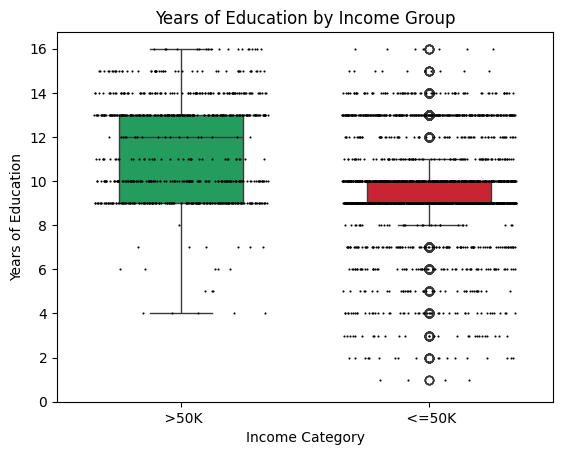

In [98]:
# Boxplot
sns.boxplot(
    x="income",
    y="education_num",
    data=sample_df,
    palette=["#10b05e", "#e3091b"],
    width=0.5,
)

# Overlay many points
sns.stripplot(
    x="income",
    y="education_num",
    data=sample_df,
    jitter=0.35,     # spreads points horizontally
    size=1.5,        # small dots so many can fit
    color="black"
)

plt.ylim(bottom=0)
plt.title("Years of Education by Income Group")
plt.xlabel("Income Category")
plt.ylabel("Years of Education")

plt.show()

### **Categorical Analyses**

For my categorical analysis, my question is; **How does income level (<=50K vs >50K) vary across different occupations?** The Adult Dataset(Census Income) is appropriate for answering this question because it includes both the categorical variables occupation and income for over again containing well over 48,000 adults, allowing me to examine how income is distributed across job types. Frequency counts and proportions were calculated for each occupation, and I created a multi-bar graph to visualize how many individuals in each occupation earn ≤50K versus >50K. This visualization was chosen because it clearly compares the distribution of income levels across occupations. Minor data cleaning was required by removing missing values represented by “?” to ensure accurate results(which was carried over from my other analysis). The income variable has two levels—≤50K (earning 50,000 or less annually) and >50K (earning more than 50,000 annually). While occupation includes categories such as professional, managerial, service, and manual labor jobs. The numerical summaries and visualization show that some occupations have a larger proportion of individuals earning more than $50K, suggesting that occupation may influence income levels. For the most part, we can see in my visualization that the trend is no matter what field you are, most jobs still do not pay well over 50k based on occupation (high majority of Adults still earn less than 50k). I also did an addition categorical analysis, to see if there was a correlation between the different races, and which majority/minorities are in this data.

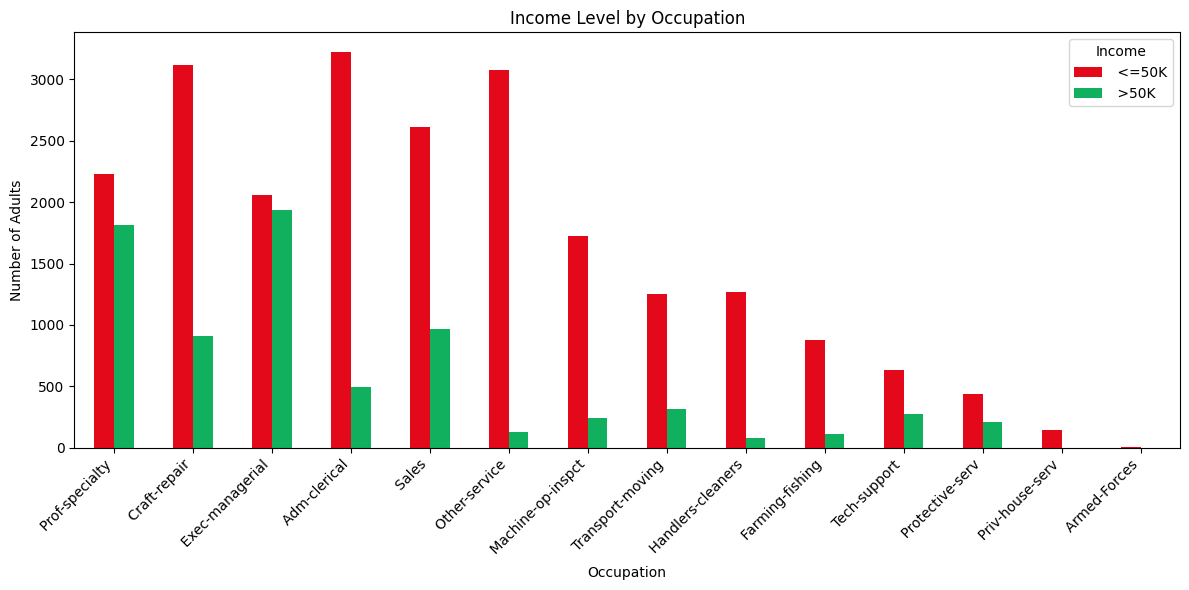

In [66]:
# Count occupations by income group
occupation_income = pd.crosstab(df["occupation"], df["income"])

# Sort by total count so the chart is easier to read
occupation_income = occupation_income.loc[occupation_income.sum(axis=1).sort_values(ascending=False).index]

# Make stacked bar chart
occupation_income.plot(
    kind="bar",
    color=["#e3091b", "#10b05e"],
    figsize=(12, 6)
)

plt.title("Income Level by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Adults")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()
plt.show()

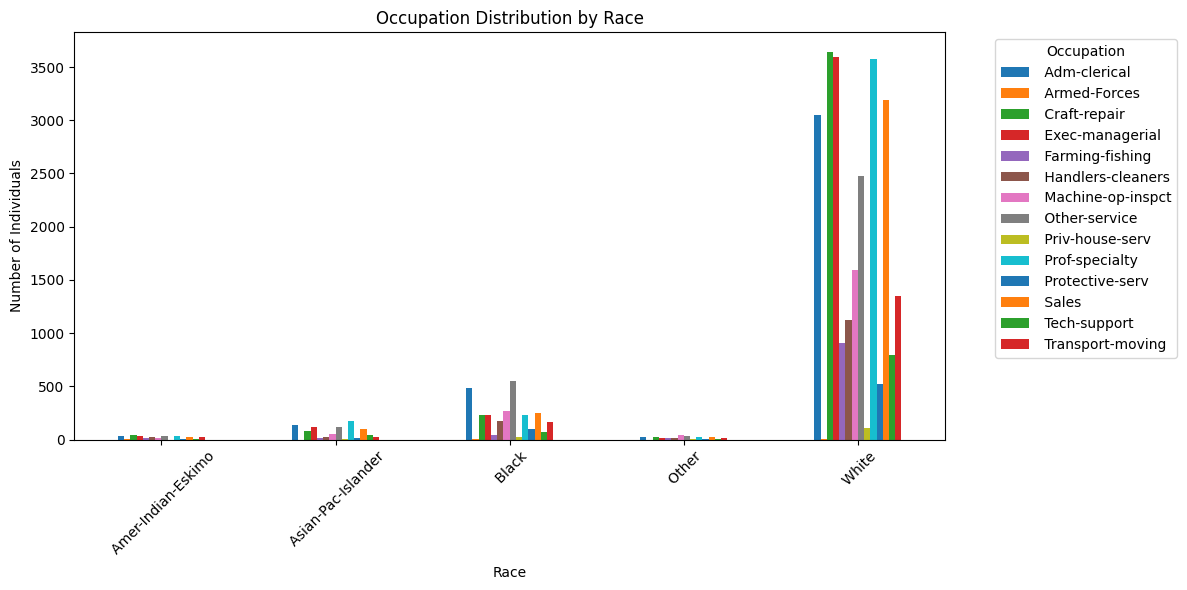

In [67]:
# Create table of race vs occupation
race_occ = pd.crosstab(df["race"], df["occupation"])

# Plot stacked bar chart
race_occ.plot(
    kind="bar",

    figsize=(12,6)
)

plt.title("Occupation Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.legend(title="Occupation", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

### **Exploratory Analyses**

For my Exploratory analysis, my question is; **How do age and hours worked per week relate to income level among adults?** A scatter plot of age versus hours worked per week, colored by income level, was used as the primary visualization. This visualization was chosen because it allows us to observe patterns or clusters between the variables and determine whether individuals earning more than $50K tend to appear within certain age ranges or work-hour levels. Scatter plots are useful in exploratory analysis because they display the relationship between two quantitative variables while also allowing a third categorical variable (income) to be represented through color. Based on the summary statistics and scatter plot, there appears to be a moderate association between these variables. Higher-income individuals tend to appear more frequently among middle-aged adults who work around full-time hours, while lower-income individuals appear across a wider range of ages and working hours. Although there is considerable overlap between the two income groups, the visualization suggests that age and hours worked may contribute to differences in income levels.

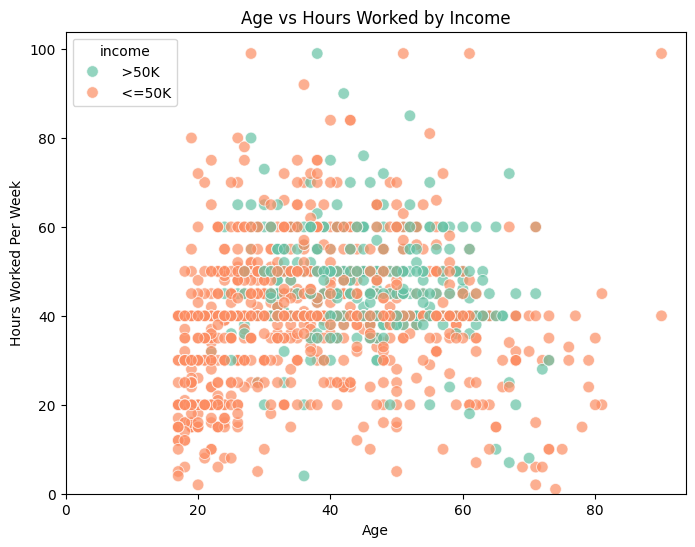

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_sample,
    x="age",
    y="hours_per_week",
    hue="income",
    palette="Set2",
    alpha=0.7,
    s=70
)

plt.title("Age vs Hours Worked by Income")
plt.xlabel("Age")
plt.ylabel("Hours Worked Per Week")
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

### **Nonparametric inference of a Median using quantitative analysis**

To continue on with correlation of age, hours worked, and income, I wanted do do a visualization on the median hours worked. I asked; **What is the median number of hours worked per week among adults in the dataset?** As seen in my visualization, I did a bar graph on a Bootstrap Distribution of Median Hours Worked per week. The distribution appears roughly symmetric and bell-shaped, centered near 41 hours. This indicates that the median estimate is not heavily skewed and that most simulated medians fall close to the center. The median number of hours worked per week among adults in the dataset is approximately 41 hours, which is also seen when I printed the mean of this dataset. The relatively narrow spread of the distribution indicates that this estimate is consistent across many simulated samples (also very clearly seen in my exploratory analysis).

In [86]:
sample_df = df.sample(frac=0.10, random_state=1)

In [94]:
mean_hours = sample_df["hours_per_week"].mean()
print(mean_hours)

41.023209549071616


In [87]:
median_hours = sample_df["hours_per_week"].median()
print(median_hours)

40.0


In [91]:
medians = []

for i in range(1000):
    boot_sample = sample_df["hours_per_week"].sample(frac=1, replace=True)
    medians.append(boot_sample.mean())

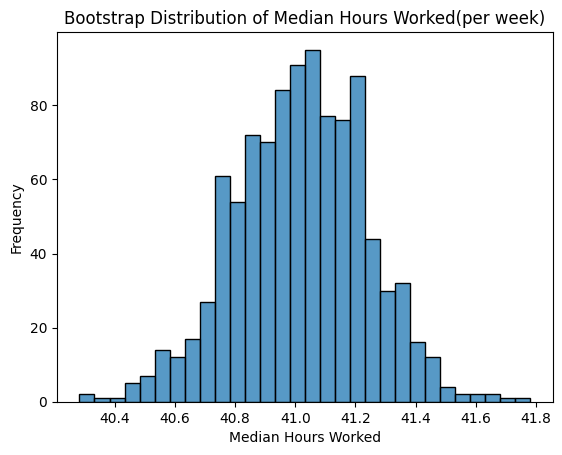

In [93]:
sns.histplot(medians, bins=30)

plt.title("Bootstrap Distribution of Median Hours Worked(per week)")
plt.xlabel("Median Hours Worked")
plt.ylabel("Frequency")

plt.show()

### **Conclusion:**  

To conclude my research analyses, I have multiple highlights to this project.

1. the variables I chose were specifically chosen, because they were the most strongly associated with higher income levels. These variables include education level, occupation, and age. Individuals with higher education levels and professional occupations are more likely to earn more than 50K annually, while younger individuals and those in service-related occupations are more likely to earn 50K or less.

2. Like mentioned in the introduction, for the biases, I can see that there is a bias between races like I said, "certain populations may be underrepresented due to non-response, limited access, or socioeconomic barriers" I can see that that is exactly what has happened.

3. I will say I would've liked to look deeper into Prof-Specialty and have a break down on the types of different profession specialities there were. Then essentially look at which ones tend to earn more than 50k annually, in comparision to those who earn less than 50k annually. Other further questions could be, are they a new time business professional, how many years have they been in that field, etc.

